# minicv Library Test Notebook

## Imports

In [2]:
from minicv import io, utils, filters, transforms, features, drawing
import numpy as np
import matplotlib.pyplot as plt

## IO Module

In [3]:
# Test IO module
img=io.read_image("Test images/messi.jpg")
io.export_image(img,"Test images/messi_mod.jpg",quality=95)

### Color Conversion

In [ ]:
#Test color conversion

#RGB to Gray
img_gray=io.rgb_to_gray(img)
io.export_image(img_gray,"Test images/messi_gray.jpg",quality=95)

#Gray to RGB
img_color=io.gray_to_rgb(img_gray)
io.export_image(img_color,"Test images/messi_color.jpg",quality=95)


#Shape verification
print("color image shape:",img_color.shape)       
print('\n')
print("gray image shape:",img_gray.shape)


color image shape: (2497, 1994, 3)


gray image shape: (2497, 1994)


## Normalization Module

In [ ]:
#Normalization module
img_norm_minmax=utils.normalize(img,mode='minmax')
img_norm_zscore=utils.normalize(img,mode='zscore')
img_norm_unit=utils.normalize(img,mode='unit')

io.export_image(img_norm_minmax,"Test images/messi_norm_minmax.jpg",quality=95)
io.export_image(img_norm_zscore,"Test images/messi_norm_zscore.jpg",quality=95)
io.export_image(img_norm_unit,"Test images/messi_norm_unit.jpg",quality=95)


#normalizing verification
print("original \n",img, '\n')
#print("norm \n",img_norm_minmax)

# unit normalization verification
print("unit \n",img_norm_unit)


original 
 [[[  5   4   2]
  [  9   8   6]
  [ 10   9   7]
  ...
  [  8   9   4]
  [  9  10   5]
  [  5   6   1]]

 [[  5   4   2]
  [ 10   9   7]
  [ 14  13  11]
  ...
  [  4   5   0]
  [ 12  13   8]
  [ 10  11   6]]

 [[ 11  10   8]
  [ 10   9   7]
  [  8   7   5]
  ...
  [  2   3   0]
  [ 10  11   6]
  [ 10  11   6]]

 ...

 [[ 81 144  37]
  [ 95 161  53]
  [102 165  58]
  ...
  [ 62 142  27]
  [ 57 136  21]
  [ 60 139  24]]

 [[ 91 154  47]
  [ 99 162  55]
  [ 84 147  40]
  ...
  [ 61 141  26]
  [ 70 149  34]
  [ 74 153  38]]

 [[ 97 158  54]
  [ 89 150  46]
  [ 88 151  46]
  ...
  [ 60 139  24]
  [ 71 148  34]
  [ 84 161  47]]] 

[[[1.17806755e-05 9.42454043e-06 4.71227021e-06]
  [2.12052160e-05 1.88490809e-05 1.41368106e-05]
  [2.35613511e-05 2.12052160e-05 1.64929457e-05]
  ...
  [1.88490809e-05 2.12052160e-05 9.42454043e-06]
  [2.12052160e-05 2.35613511e-05 1.17806755e-05]
  [1.17806755e-05 1.41368106e-05 2.35613511e-06]]

 [[1.17806755e-05 9.42454043e-06 4.71227021e-06]
  [2.3

## Clipping

In [5]:
img_clip=utils.clip_pixels(img, lo =0, hi=100)
io.export_image(img_clip,"Test images/messi_clip.jpg",quality=95)

## Padding

In [6]:
#Padding module
img_pad1=utils.pad(img,20,20,mode='constant',constant_value=255)
io.export_image(img_pad1,"Test images/messi_pad1.jpg",quality=95)

img_pad2=utils.pad(img,20,20,mode='replicate')
io.export_image(img_pad2,"Test images/messi_pad2.jpg",quality=95)

img_pad3=utils.pad(img,50,50,mode="reflect")
io.export_image(img_pad3,"Test images/messi_pad3.jpg",quality=95)

## Convoluion

In [7]:
kernel = np.ones((9, 9)) * (1.0 / 36.0)
#kernel=np.array([[1 ,2, 3],[[],[] ,5],[1,1,1]])
img_conv=utils.convolve2d(img_gray,kernel,pad_mode="constant")
io.export_image(img_conv,"Test images/messi_conv.jpg",quality=95)

## Filtering


In [8]:
img_mean_filtered=filters.mean_filter(img,kernel_size=9,pad_mode='constant')
io.export_image(img_mean_filtered,"Test images/messi_mean_filtered.jpg",quality=95)

img_gaussian = filters.gaussian_filter(img, size=11, sigma=1.5, pad_mode='reflect')
io.export_image(img_gaussian, "Test images/messi_gaussian.jpg", quality=95)

img_median = filters.median_filter(img_gray, kernel_size=11, pad_mode='reflect')
io.export_image(img_median, "Test images/messi_median.jpg", quality=95)

In [9]:
img_global_thresh = filters.threshold_global(img_gray, thresh=0.5, max_val=1.0)
io.export_image(img_global_thresh, "Test images/messi_global_thresh.jpg", quality=95)

img_otsu, val = filters.threshold_otsu(img_gray)
io.export_image(img_otsu, "Test images/messi_otsu.jpg", quality=95)

img_adaptive = filters.threshold_adaptive(img_gray, block_size=11, C=0.02, method='mean')
io.export_image(img_adaptive, "Test images/messi_adaptive.jpg", quality=95)

In [10]:
sobel_results = filters.sobel_gradients(img_gray)
img_sobel_mag = sobel_results['magnitude']
io.export_image(img_sobel_mag, "Test images/messi_sobel_magnitude.jpg", quality=95)

img_laplacian = filters.laplacian_filter(img_gray)
io.export_image(img_laplacian, "Test images/messi_laplacian.jpg", quality=95)

img_equalized = filters.equalize_histogram(img_gray)
io.export_image(img_equalized, "Test images/messi_equalized.jpg", quality=95)

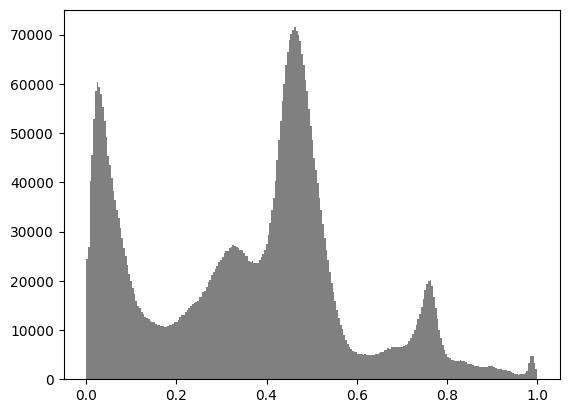

In [11]:


img_unsharp = filters.unsharp_mask(img, sigma=1.0, strength=10.0)
io.export_image(img_unsharp, "Test images/messi_unsharp.jpg", quality=95)

img_bit_slice = filters.bit_plane_slice(img_gray, plane=3)
io.export_image(img_bit_slice, "Test images/messi_bit_slice.jpg", quality=95)

counts, edges = filters.histogram(img_gray, bins=256)

plt.bar(edges[:-1], counts, width=np.diff(edges), color='gray', align='edge')
plt.show()

## Transformations

In [5]:
img_resize1=transforms.resize(img,1000,1000,interpolation='bilinear')
io.export_image(img_resize1, "Test images/messi_resize1_bilinear.jpg", quality=95)

img_rot=transforms.rotate(img,45,interpolation='bilinear',fill=0.0)
io.export_image(img_rot, "Test images/messi_rotated_bilinear.jpg", quality=95)

img_trans=transforms.translate(img, 20, 20,interpolation='bilinear',fill=0.0)
io.export_image(img_trans, "Test images/messi_translated_bilinear.jpg", quality=95)

## Feauture Extraction

## Global Descriptors

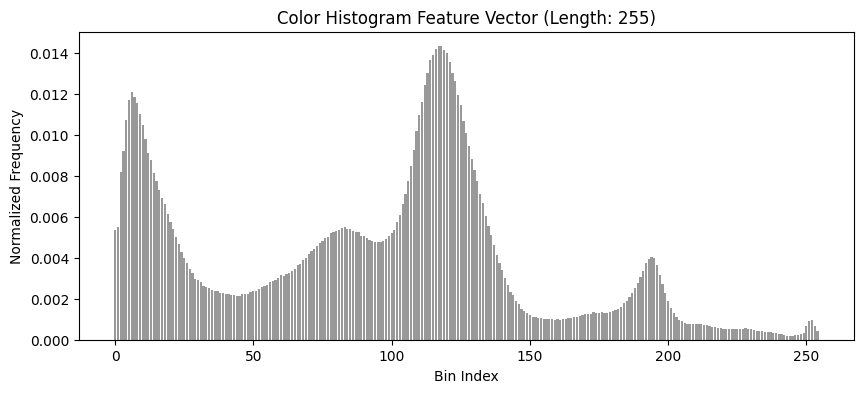

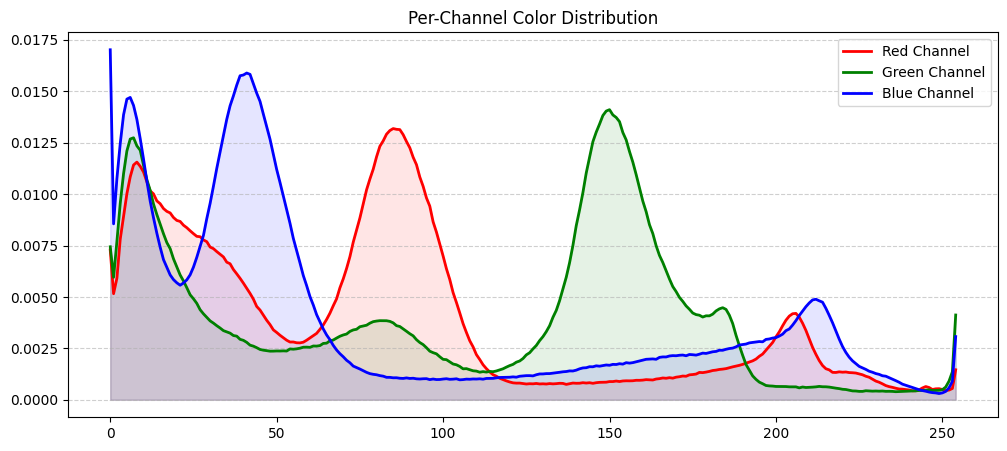

[0.3629878  0.22449635 0.         0.9999     0.14733351]


In [13]:

#Gray image
color_histogram=features.color_histogram(img_gray, bins=255)
plt.figure(figsize=(10, 4))
plt.bar(range(len(color_histogram)), color_histogram, color='gray', alpha=0.8)
plt.title(f"Color Histogram Feature Vector (Length: {len(color_histogram)})")
plt.xlabel("Bin Index")
plt.ylabel("Normalized Frequency")
plt.show()

##RGB color histogram
color_hist = features.color_histogram(img, bins=255)

# Split the concatenated vector into R, G, B components
r_hist = color_hist[0:255]
g_hist = color_hist[255:2*255]
b_hist = color_hist[2*255:3*255]

# Plotting
plt.figure(figsize=(12, 5))
x = np.arange(255)

plt.plot(x, r_hist, color='red', label='Red Channel', linewidth=2)
plt.plot(x, g_hist, color='green', label='Green Channel', linewidth=2)
plt.plot(x, b_hist, color='blue', label='Blue Channel', linewidth=2)

plt.fill_between(x, r_hist, color='red', alpha=0.1)
plt.fill_between(x, g_hist, color='green', alpha=0.1)
plt.fill_between(x, b_hist, color='blue', alpha=0.1)

plt.title("Per-Channel Color Distribution")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

#pixel statistics
output =features.pixel_statistics(img_gray)
#By order mean, sigma, min, max, skewness
print(output)

## Gradient Descriptors

### Gradient Histogram (HOG)

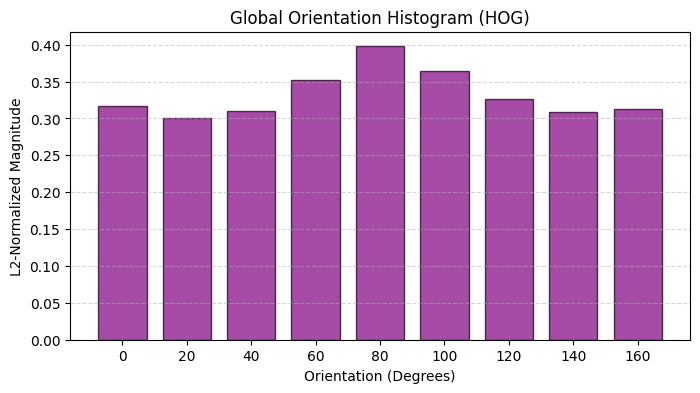

In [14]:
#Gradeient histogram
hog_feat = features.gradient_histogram(img_gray, bins=9, signed=False)
plt.figure(figsize=(8, 4))
angles = np.linspace(0, 180, len(hog_feat), endpoint=False)
plt.bar(angles, hog_feat, width=15, color='purple', edgecolor='black', alpha=0.7)
plt.title("Global Orientation Histogram (HOG)")
plt.xlabel("Orientation (Degrees)")
plt.ylabel("L2-Normalized Magnitude")
plt.xticks(angles)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Local Binary Pattern (LBP)

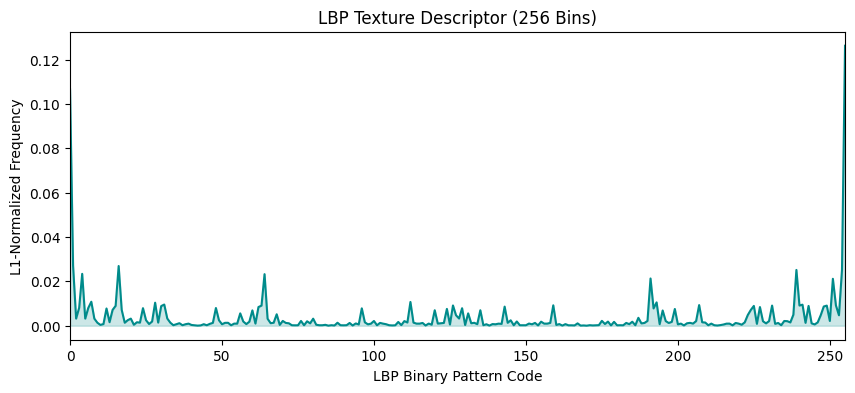

In [15]:
#LBP
lbp_feat = features.lbp(img_gray, radius=1, n_points=8, bins=256)
plt.figure(figsize=(10, 4))
plt.plot(lbp_feat, color='darkcyan', linewidth=1.5)
plt.fill_between(range(len(lbp_feat)), lbp_feat, color='darkcyan', alpha=0.2)
plt.title("LBP Texture Descriptor (256 Bins)")
plt.xlabel("LBP Binary Pattern Code")
plt.ylabel("L1-Normalized Frequency")
plt.xlim([0, 255])
plt.show()

## Drawing Module

In [ ]:

#Drawing module
img_point=img.copy()   #Deep copy
drawing.draw_point(img_point, 100, 100,color=(255,255, 0),radius=50 )
io.export_image(img_point, "Test images/messi_with_point.jpg", quality=95)


img_line=img.copy()
drawing.draw_line(img_line,0,0, 200,200,color=(255,255, 0),thickness=20)
io.export_image(img_line, "Test images/messi_with_line.jpg", quality=95)

img_rec=img.copy()
drawing.draw_rectangle(img_rec,0,0, 200,200,color=(255,255, 0),thickness=20,filled=False)
io.export_image(img_rec, "Test images/messi_with_rectangle_non-filled.jpg", quality=95)


img_pol=img.copy()
points = [(400, 250), (550, 350), (350, 380)]
drawing.draw_polygon(img_pol,points,color=(255,255, 0),thickness=20,filled=True)
io.export_image(img_pol, "Test images/messi_with_polygon_filled.jpg", quality=95)



## TEXT

In [17]:
img_txt=img.copy()
text="goallllll!"
drawing.put_text(img_txt,text,200,200,color=(255,255, 0),scale=10 )
io.export_image(img_txt, "Test images/messi_with_text.jpg", quality=95)